# G2 — Multi-país (FIN+SWE+NOR) y la pregunta del momentum

**EXP-002**. Dataset: 4.941 partidos, 17 ligas, 3 países. Corrida pesada en
`research/experiments/EXP-002-multiliga/run.py`; acá se analizan los artefactos.

Preguntas: (1) ¿generaliza la escalera de EXP-001? (2) ¿las features de
forma ajustada por rival (Elo, momentum, sobre-rendimiento, SoS, PPG vs
más fuertes) agregan sobre Dixon-Coles? Informe completo con conclusiones:
`../experiments/EXP-002-multiliga/report.md`.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = Path.cwd()
for p in [here, *here.parents]:
    if (p / 'research').is_dir():
        ROOT = p; sys.path.insert(0, str(p)); break
from research.peak_models import loader
from research.peak_models.evaluate import PCOLS, compare, rps_per_match, paired_bootstrap

EXP = ROOT / 'research' / 'experiments' / 'EXP-002-multiliga'
res = pd.read_csv(EXP / 'walkforward_2026.csv', parse_dates=['date'])
res['match_id'] = res['match_id'].astype(str)
meta = loader.load_all()[['match_id','country']].drop_duplicates('match_id')
res = res.merge(meta, on='match_id', how='left')
res['rps'] = rps_per_match(res[PCOLS].to_numpy(), res['result'].to_numpy())
print('partidos 2026:', res.match_id.nunique(), '| modelos:', sorted(res.model.unique()))

partidos 2026: 1619 | modelos: ['b0_base_rate', 'dc_best', 'g0_logistic_dppg', 'stack_cal', 'stack_full']


## 1. Tabla principal (RPS primaria; bootstrap pareado vs Dixon-Coles)

In [2]:
compare(res, baseline='dc_best').round(4)

,n,rps,log_loss,brier,ece_home,accuracy,d_rps_vs_base,d_rps_ci,p_better_rps,d_logloss_vs_base,p_better_logloss
model,,,,,,,,,,,
stack_cal,1619,0.2132,0.9940,0.5932,0.0282,0.5312,-0.0007,"(-0.0015, 0.0001)",0.9598,-0.0067,0.9978
dc_best,1619,0.2139,1.0007,0.5958,0.0310,0.5324,NaN,NaN,NaN,NaN,NaN
stack_full,1619,0.2139,0.9968,0.5952,0.0276,0.5201,0.0001,"(-0.0021, 0.0022)",0.4630,-0.0039,0.7995
g0_logistic_dppg,1619,0.2225,1.0243,0.6136,0.0274,0.5090,0.0086,"(0.0032, 0.0139)",0.0008,0.0236,0.0040
b0_base_rate,1619,0.2377,1.0633,0.6439,0.0477,0.4441,0.0238,"(0.017, 0.0308)",0.0000,0.0626,0.0000


**G2 superado**: G0 pierde contra DC con IC 95% (+0.0032, +0.0139), p<0.001
en log-loss, 1.619 partidos. `stack_cal` (recalibración OOS) mejora log-loss
con p≈0.998 y nunca empeora → capa estándar. `stack_full` (≈DC): las
features de momentum **no pagan su lugar** — ver §3.

## 2. RPS por país y por liga

In [3]:
print(res.groupby(['model','country'])['rps'].mean().unstack().round(4).to_string())
by_lg = res.groupby(['model','league_code'])['rps'].mean().unstack().round(4)
by_lg.reindex(['b0_base_rate','g0_logistic_dppg','dc_best','stack_cal','stack_full'])

country              FIN     NOR     SWE
model                                   
b0_base_rate      0.2377  0.2404  0.2354
dc_best           0.2107  0.2144  0.2160
g0_logistic_dppg  0.2190  0.2214  0.2263
stack_cal         0.2106  0.2127  0.2157
stack_full        0.2116  0.2130  0.2167


league_code,M1,M1L,M2,NL,NO-1DK,NO-ELI,NO-OBOS,NO-PN1,NO-PN2,NO-TS,SW-AL,SW-DA,SW-EE,SW-EN,SW-ES,SW-SE,VL
model,,,,,,,,,,,,,,,,,
b0_base_rate,0.2430,0.2356,0.2382,0.2575,0.2530,0.2247,0.2357,0.2492,0.2447,0.2442,0.2325,0.2358,0.2429,0.2393,0.2307,0.2340,0.2226
g0_logistic_dppg,0.2282,0.2203,0.2239,0.2050,0.2082,0.2295,0.2231,0.2069,0.2282,0.2281,0.2199,0.2077,0.2041,0.2291,0.2331,0.2482,0.2070
dc_best,0.2376,0.2194,0.2118,0.1534,0.2058,0.2002,0.2357,0.2295,0.2128,0.1926,0.2232,0.1872,0.1771,0.2265,0.2226,0.2352,0.2077
stack_cal,0.2350,0.2198,0.2111,0.1580,0.2025,0.2000,0.2319,0.2266,0.2138,0.1921,0.2221,0.1867,0.1791,0.2250,0.2222,0.2353,0.2082
stack_full,0.2375,0.2157,0.2142,0.1515,0.2037,0.2018,0.2320,0.2224,0.2156,0.1928,0.2276,0.1899,0.1775,0.2227,0.2254,0.2334,0.2117


Las ligas **femeninas** (NL 0.151, SW-EE 0.177, SW-DA 0.187, NO-TS 0.193 con
DC) son las más predecibles del dataset — candidatas #1 a buscar value.
La anomalía M1 (Ykkönen) persiste (DC pierde vs G0 solo ahí) → EXP-003a.

## 3. ¿'Viene ganando contra equipos buenos' aporta? (ablación)

In [4]:
pm = {m: g.set_index('match_id')['rps'] for m, g in res.groupby('model')}
ids = pm['stack_cal'].index.intersection(pm['stack_full'].index)
bs = paired_bootstrap(pm['stack_cal'].loc[ids].to_numpy(), pm['stack_full'].loc[ids].to_numpy())
print('ΔRPS stack_full − stack_cal: %.4f  IC95%% (%.4f, %.4f)  P(features ayudan)=%.2f'
      % (bs['delta_mean'], bs['ci_lo'], bs['ci_hi'], bs['p_better']))

ΔRPS stack_full − stack_cal: 0.0008  IC95% (-0.0013, 0.0029)  P(features ayudan)=0.23


La señal **existe univariadamente** (28%→59% de victoria local entre quintiles
de sobre-rendimiento; ver `fig/momentum_effect.png`) pero el DC con decaimiento
de 120 días **ya la contiene**: la verosimilitud ponderada en el tiempo sobre el
grafo de partidos ES forma ajustada por rival. Aditivamente: cero. Coeficientes
del meta-modelo ≈0 para elo/mom5/SoS (fig/stack_coefficients.png).

## 4. Figuras del informe

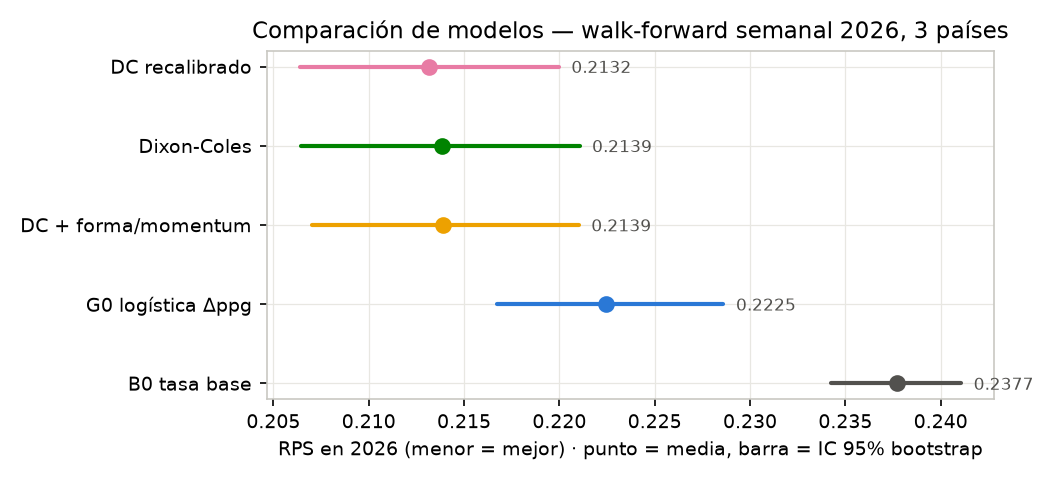

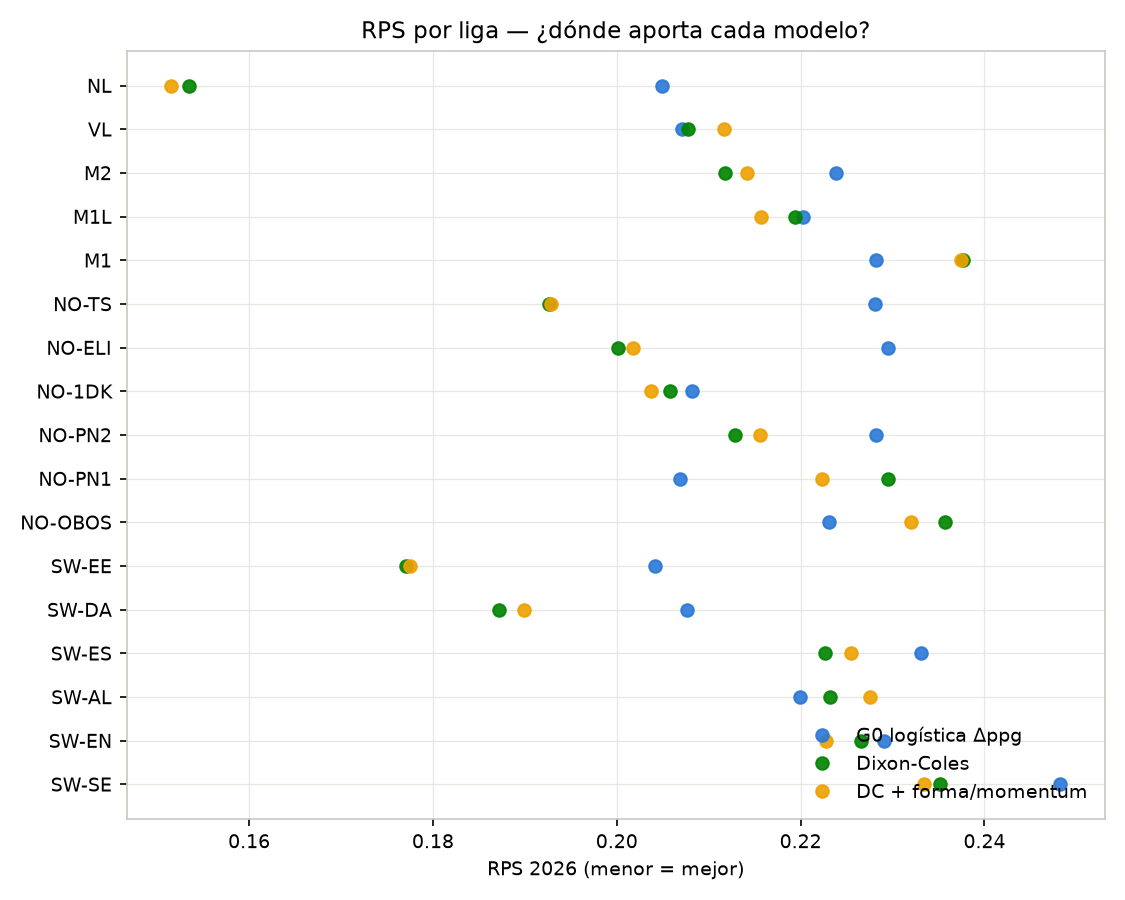

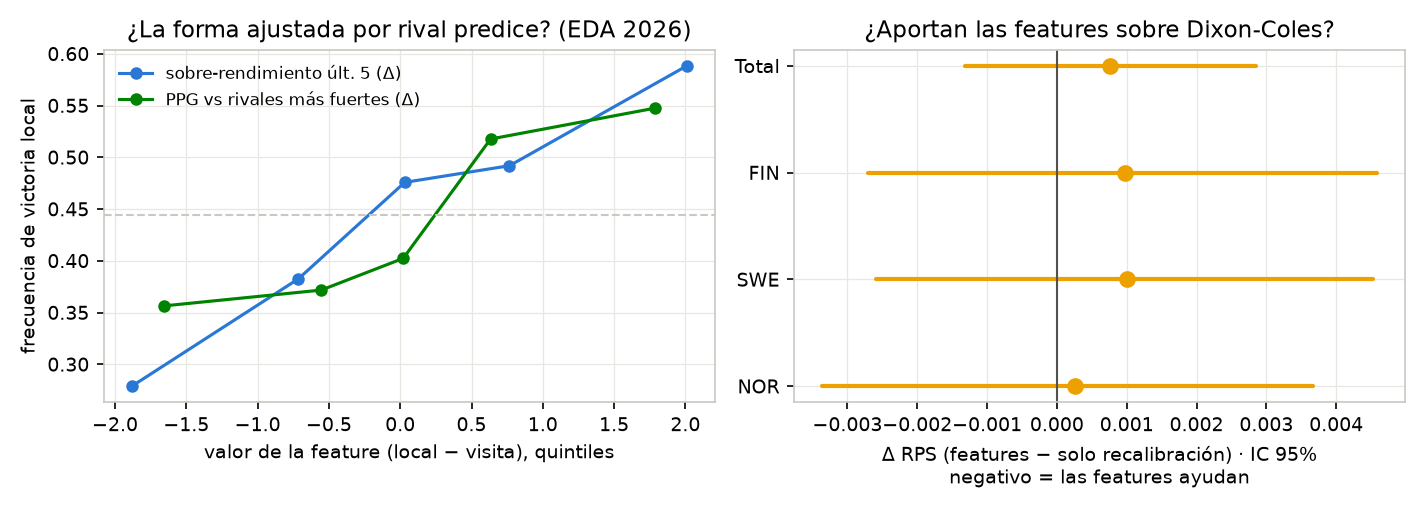

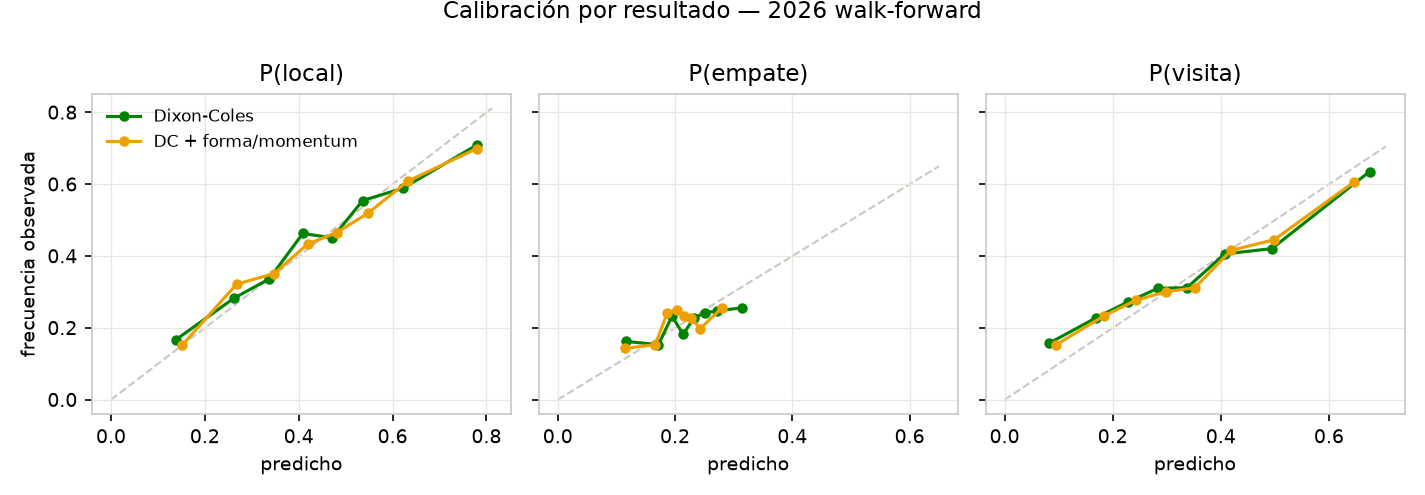

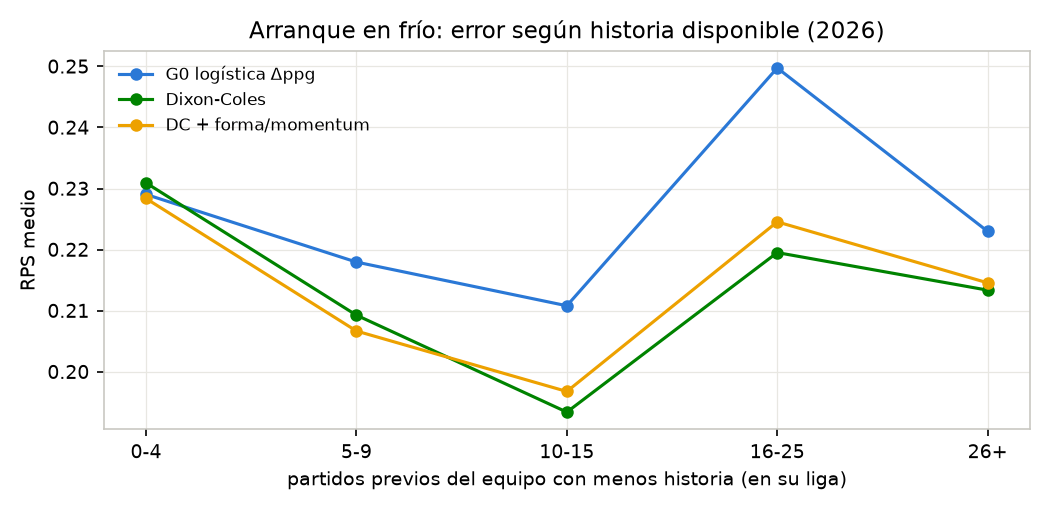

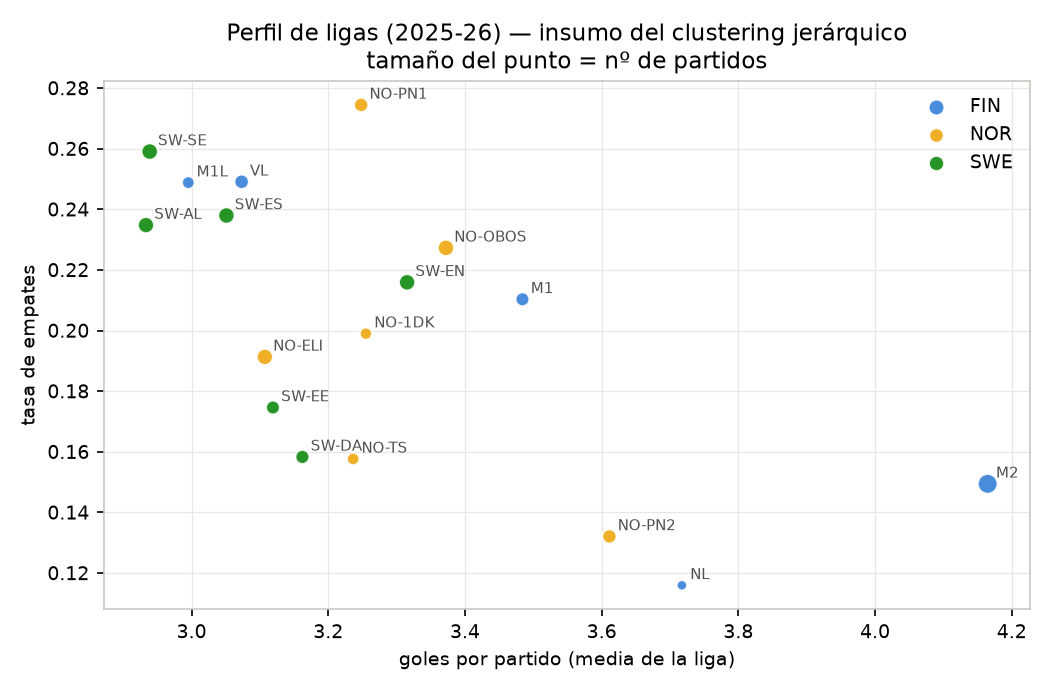

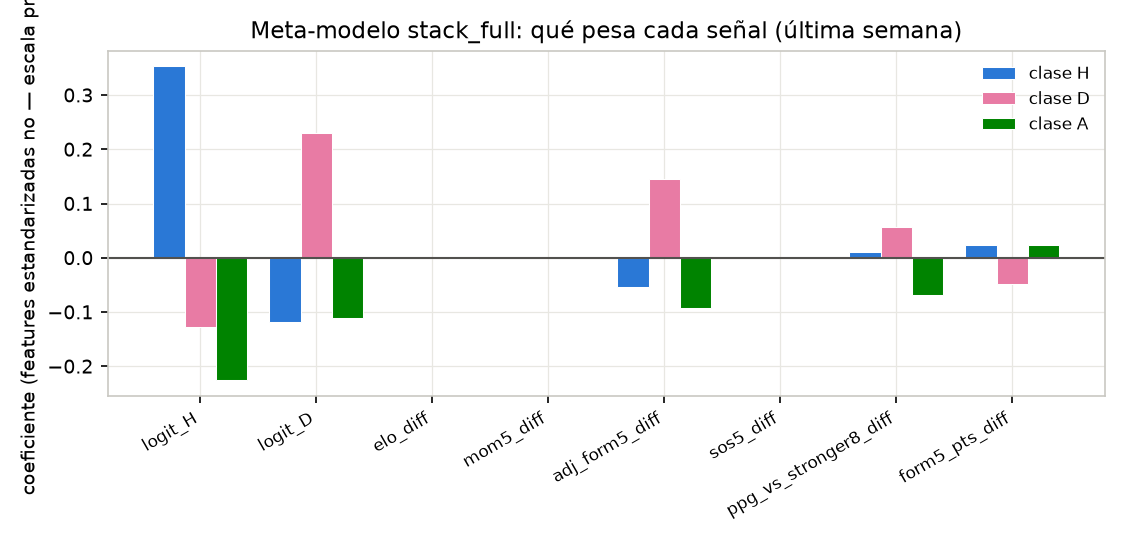

In [5]:
from IPython.display import Image, display
for f in ['model_comparison','rps_by_league','momentum_effect','calibration',
          'cold_start','league_profiles','stack_coefficients']:
    display(Image(filename=EXP / 'fig' / f'{f}.png'))

## 5. Conclusiones y siguiente paso

- Modelo candidato a producción: **DC(hl=120, σ=0.75, ρ) + recalibración OOS**.
- Empates sobre-estimados en la cola alta → no jugarlos aún.
- Features de forma lineales: descartadas con evidencia (protocolo §3.5).
- Próximos: jerárquico bayesiano con clustering (perfiles listos), diagnóstico
  M1, Islandia via sportradar, targets O/U-BTTS, y **Fase 0 de cuotas** para
  pasar de RPS a EV/ROI/CLV.